<a href="https://colab.research.google.com/github/Felantina06/ProjetIA-initiation/blob/main/RNAProjet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q tensorflow
!pip install -q scikit-learn
!pip install -q pandas
!pip install -q matplotlib
!pip install -q seaborn


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

Charger le dataset

In [ ]:
import pandas as pd

df = pd.read_csv("kidney_disease.csv")

Exploration des données (EDA)

In [ ]:
display(df.head())

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
df.tail()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd
399,399,58.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,53,6800,6.1,no,no,no,good,no,no,notckd


In [ ]:
df.shape

(400, 26)

In [ ]:
df.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [ ]:
display(df.describe())

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [ ]:
df.dtypes

,0
id,int64
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,object
pc,object
pcc,object
ba,object


Vérification des valeurs manquantes

In [ ]:
df.isnull().sum()

,0
id,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4


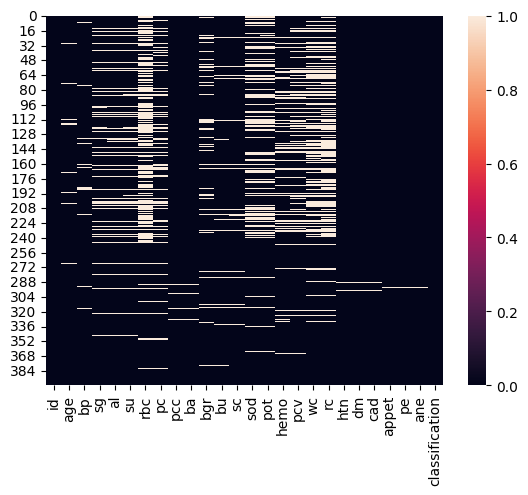

In [ ]:
sns.heatmap(df.isnull())
plt.show()

Suppression des doublons

In [ ]:
df = df.drop_duplicates()

Traitement des valeurs manquantes :Colonnes numériques :

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy='median')

df[num_cols] = imputer.fit_transform(df[num_cols])

Colonnes catégorielles :

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_3977/2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Encodage

In [ ]:
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

Analyse graphique

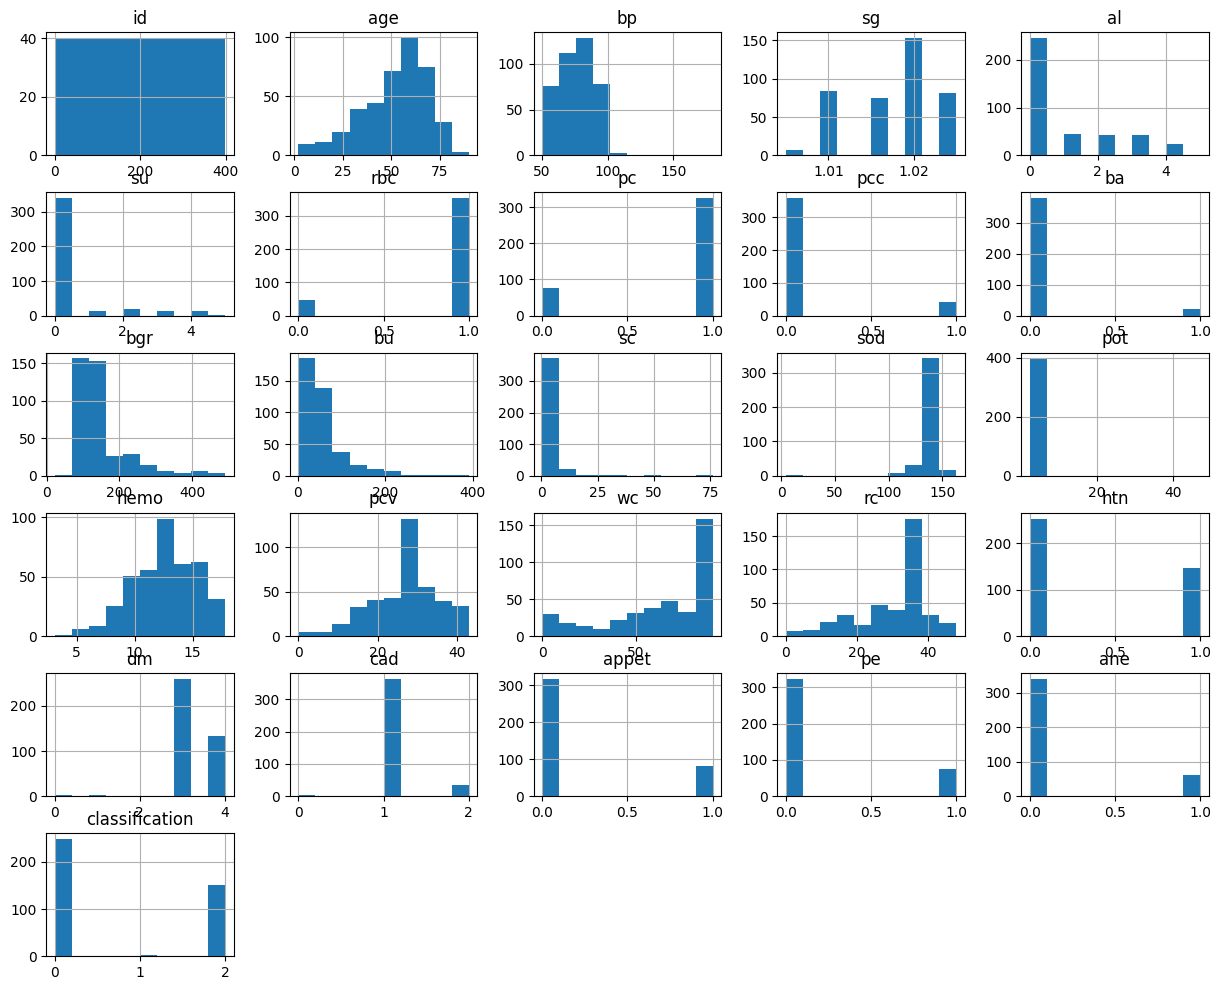

In [ ]:
df.hist(figsize=(15,12))
plt.show()

Matrice de corrélation

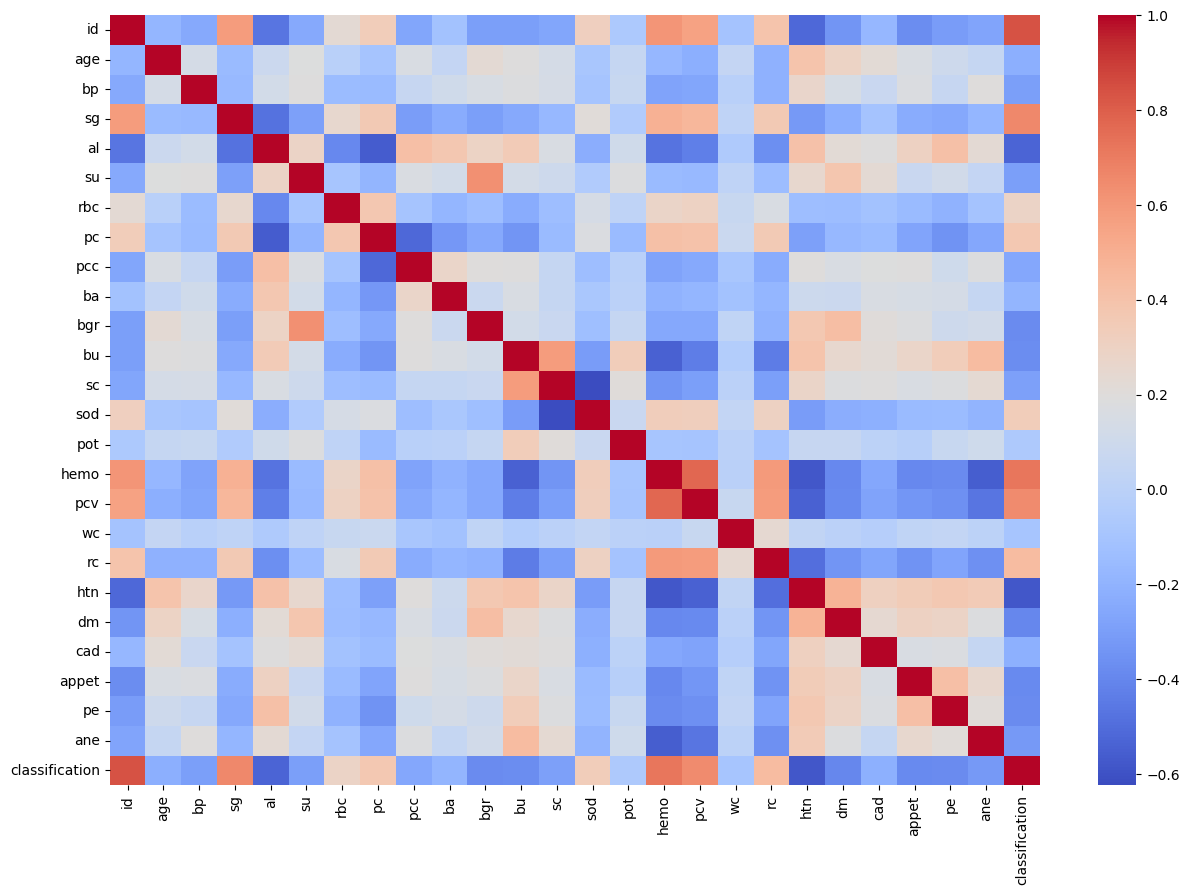

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

Boxplots

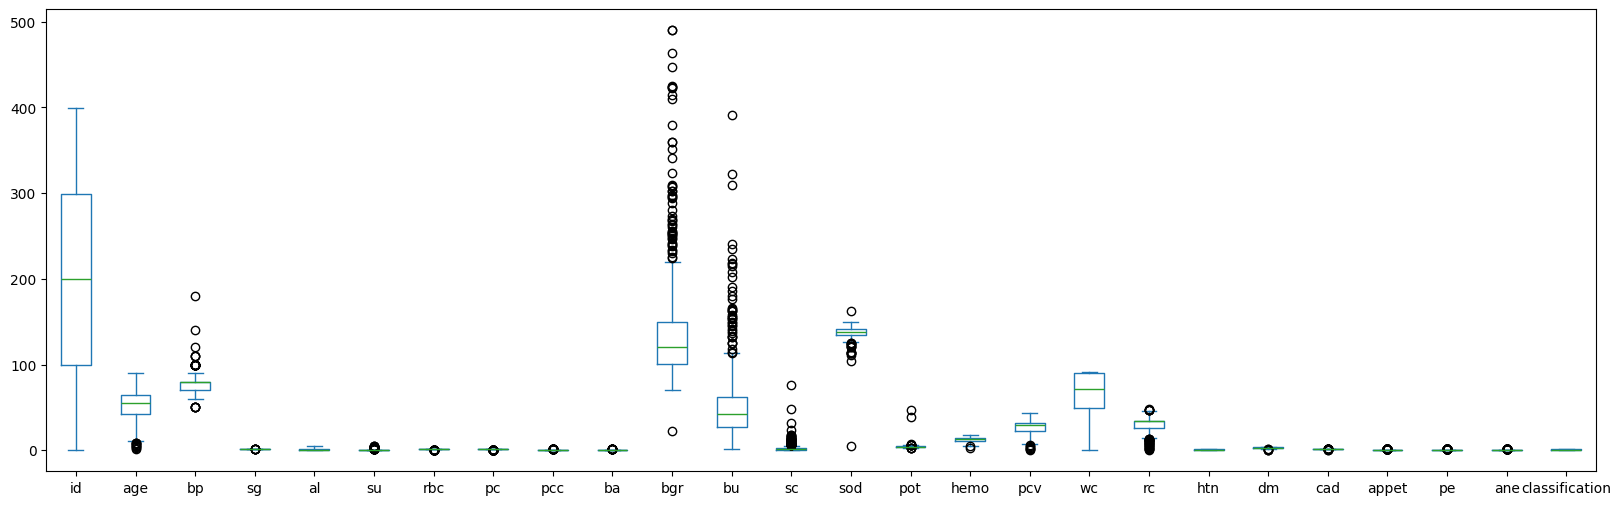

In [ ]:
df.plot(kind='box', figsize=(20,6))
plt.show()

Sélection des variables

In [23]:
X = df.drop("classification", axis=1)

y = df["classification"]

Normalisation

In [24]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

Division Train/Test

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Construction du RNA

In [26]:
model = Sequential()

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.30))

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.20))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

Compilation

In [27]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

Entraînement

In [28]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.2222 - mae: 0.8248 - val_loss: 0.8269 - val_mae: 0.7201
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4992 - mae: 0.5707 - val_loss: 0.2493 - val_mae: 0.3977
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2775 - mae: 0.4013 - val_loss: 0.1775 - val_mae: 0.3006
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2260 - mae: 0.3396 - val_loss: 0.1176 - val_mae: 0.2547
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1676 - mae: 0.2935 - val_loss: 0.1054 - val_mae: 0.2404
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1464 - mae: 0.2798 - val_loss: 0.0948 - val_mae: 0.2299
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1310 - mae: 0.2472 - val_loss: 0.0740 - val_mae: 0.1997
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1434 - mae: 0.2487 - val_loss: 0.0709 - val_mae: 0.1928
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1166 - mae: 0.2406 -

Prédiction

In [29]:
loss, mae = model.evaluate(X_test, y_test)

print(loss)
print(mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0577 - mae: 0.1547  
0.057671207934617996
0.15474621951580048


In [31]:
prediction = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


Mesures de performance

In [32]:
mae = mean_absolute_error(y_test, prediction)

mse = mean_squared_error(y_test, prediction)

rmse = np.sqrt(mse)

print(mae)
print(mse)
print(rmse)

0.15474621951580048
0.057671211659908295
0.24014831179899704


Courbes d'apprentissage

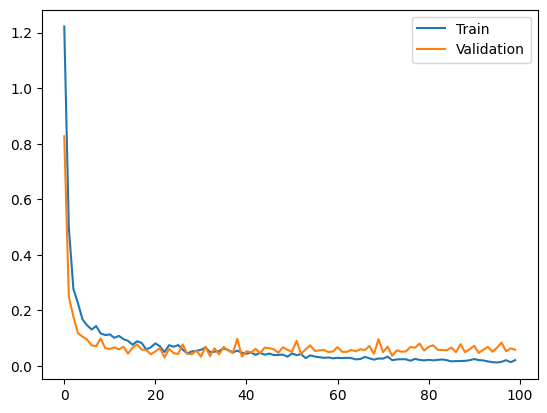

In [33]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(["Train","Validation"])

plt.show()

MAE

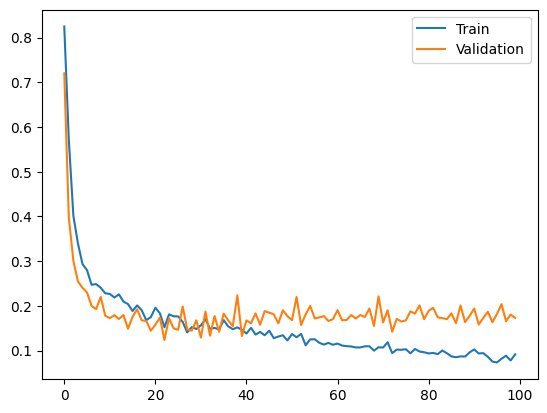

In [34]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])

plt.legend(["Train","Validation"])

plt.show()

Sauvegarde du modèle

In [35]:
model.save("rna_kidney_survival.keras")

Charger le modèle

In [36]:
model = tf.keras.models.load_model("rna_kidney_survival.keras")

Tester un nouveau patient

In [38]:
new_patient = np.array([
    [
        0.0, 48.0, 80.0, 1.020, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 120.0, 40.0, 1.0, 140.0, 4.0, 12.0, 40.0, 8000.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    ]
])

new_patient = scaler.transform(new_patient)

prediction = model.predict(new_patient)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[[-4.22799]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [39]:
# Define the threshold for classification. Assuming 0 and 2 are the encoded classes.
class_threshold = 1.0

# Apply the threshold to the prediction
predicted_class_encoded = np.where(prediction < class_threshold, 0, 2)

# Map the encoded class back to its original label
# Assuming 0 -> 'ckd' and 2 -> 'notckd' based on the dataset's typical encoding.
# If you have the original LabelEncoder object, you can use: encoder.inverse_transform(predicted_class_encoded)
class_labels = {0: 'ckd', 2: 'notckd'}
predicted_class_label = class_labels[predicted_class_encoded[0][0]]

print(f"The predicted class (encoded) for the new patient is: {predicted_class_encoded[0][0]}")
print(f"The predicted class for the new patient is: {predicted_class_label}")

The predicted class (encoded) for the new patient is: 0
The predicted class for the new patient is: ckd


In [41]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Generate continuous predictions for the entire X_test dataset
y_pred_test_continuous = model.predict(X_test)

# Convert continuous predictions on X_test to discrete class labels using the same threshold
# Assuming the 'model' is a regression model outputting values that need thresholding.
predicted_classes_test_encoded = np.where(y_pred_test_continuous < class_threshold, 0, 2)

# Ensure y_test is also in a comparable format (numpy array for confusion_matrix)
y_test_array = y_test.values if isinstance(y_test, pd.Series) else y_test

# Calculate the confusion matrix
cm = confusion_matrix(y_test_array, predicted_classes_test_encoded)
print("Confusion Matrix:")
print(cm)

# Calculate the accuracy score
accuracy = accuracy_score(y_test_array, predicted_classes_test_encoded)
print(f"\nAccuracy: {accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Confusion Matrix:
[[52  0]
 [ 0 28]]

Accuracy: 1.0000


In [42]:
model.save("rna_kidney_survival.keras")

### Modèle enregistré avec succès